# $(SA) Triplet$

<!-- $loss = mse(\hat{\theta'},\hat{\theta}) + mse(\hat{s''},s'') + mse(\hat{s'''},y)$  -->
$loss = max\{||\hat{\theta_i^a} - \hat{\theta_j^a}|| - ||\hat{\theta_i^a} - \hat{\theta_k^b}|| + \alpha, 0\}$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Triplet_Loss
from pmbrl.data import Experiment_Data

# Training

In [2]:
data = Experiment_Data()

data.generate_episodes(10)
data.build_training_dataset()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__
121,24,5,"(0.61, 1.9)","[0.015, 0.029, 0.018, 0.016]",0,1.0,"[0.016, -0.158, 0.018, 0.142]",1.0,1.0,"[0.012, 0.029, 0.021, 0.021]"
33,2,1,"(0.57, 1.3)","[-0.001, 0.046, -0.03, 0.032]",1,1.0,"[0.0, 0.235, -0.03, -0.145]",1.0,1.0,"[0.005, 0.425, -0.033, -0.322]"
85,9,4,"(0.98, 1.7)","[0.09, -0.194, -0.011, 0.248]",0,1.0,"[0.087, -0.387, -0.006, 0.487]",0.0,1.0,"[0.079, -0.579, 0.003, 0.727]"
138,41,5,"(0.61, 1.9)","[-0.066, -0.538, 0.095, 0.49]",0,1.0,"[-0.076, -0.726, 0.105, 0.624]",0.0,1.0,"[-0.091, -0.914, 0.117, 0.759]"
56,0,2,"(0.68, 1.2)","[-0.024, -0.02, 0.031, -0.041]",0,1.0,"[-0.024, -0.212, 0.031, 0.178]",0.0,1.0,"[-0.028, -0.404, 0.034, 0.397]"
...,...,...,...,...,...,...,...,...,...,...
32,1,1,"(0.57, 1.3)","[0.002, -0.144, -0.035, 0.21]",1,1.0,"[-0.001, 0.046, -0.03, 0.032]",1.0,1.0,"[0.0, 0.235, -0.03, -0.145]"
182,20,7,"(0.51, 1.5)","[-0.032, -0.715, 0.069, 0.572]",0,1.0,"[-0.046, -0.903, 0.08, 0.721]",1.0,1.0,"[-0.065, -0.716, 0.095, 0.594]"
120,23,5,"(0.61, 1.9)","[0.018, -0.158, 0.015, 0.137]",1,1.0,"[0.015, 0.029, 0.018, 0.016]",0.0,1.0,"[0.016, -0.158, 0.018, 0.142]"
132,35,5,"(0.61, 1.9)","[-0.035, -0.161, 0.062, 0.189]",1,1.0,"[-0.038, 0.026, 0.066, 0.074]",0.0,1.0,"[-0.038, -0.161, 0.068, 0.205]"


In [3]:
model = Model(transition_criterion_clss=Triplet_Loss)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=500, margin=.5)
train_data = data.get_training_data(trainer)
train_data.head()

,epoch,triplet,mse_s,transition,reward
0,0,1.119077,"[0.16308407485485077, 0.5584057569503784, 0.02...",2.655901,0.328745
1,1,1.119073,"[0.15986284613609314, 0.5524997711181641, 0.02...",2.634907,0.328687
2,2,1.119065,"[0.1568751037120819, 0.5466805100440979, 0.020...",2.614244,0.328645
3,3,1.119053,"[0.153971865773201, 0.5409521460533142, 0.0199...",2.593910,0.328603
4,4,1.119036,"[0.1511337161064148, 0.5353106260299683, 0.019...",2.573894,0.328556


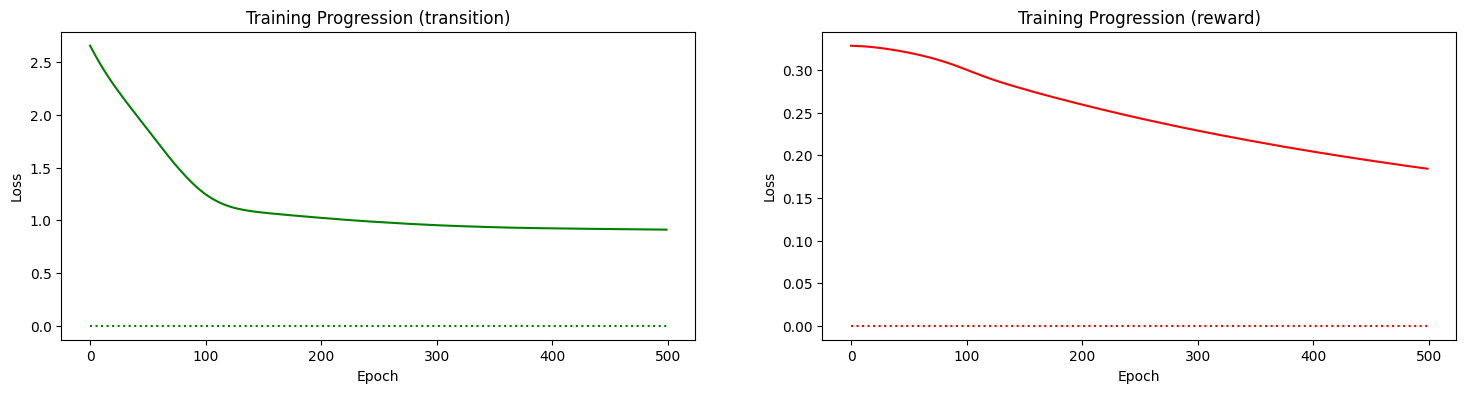

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

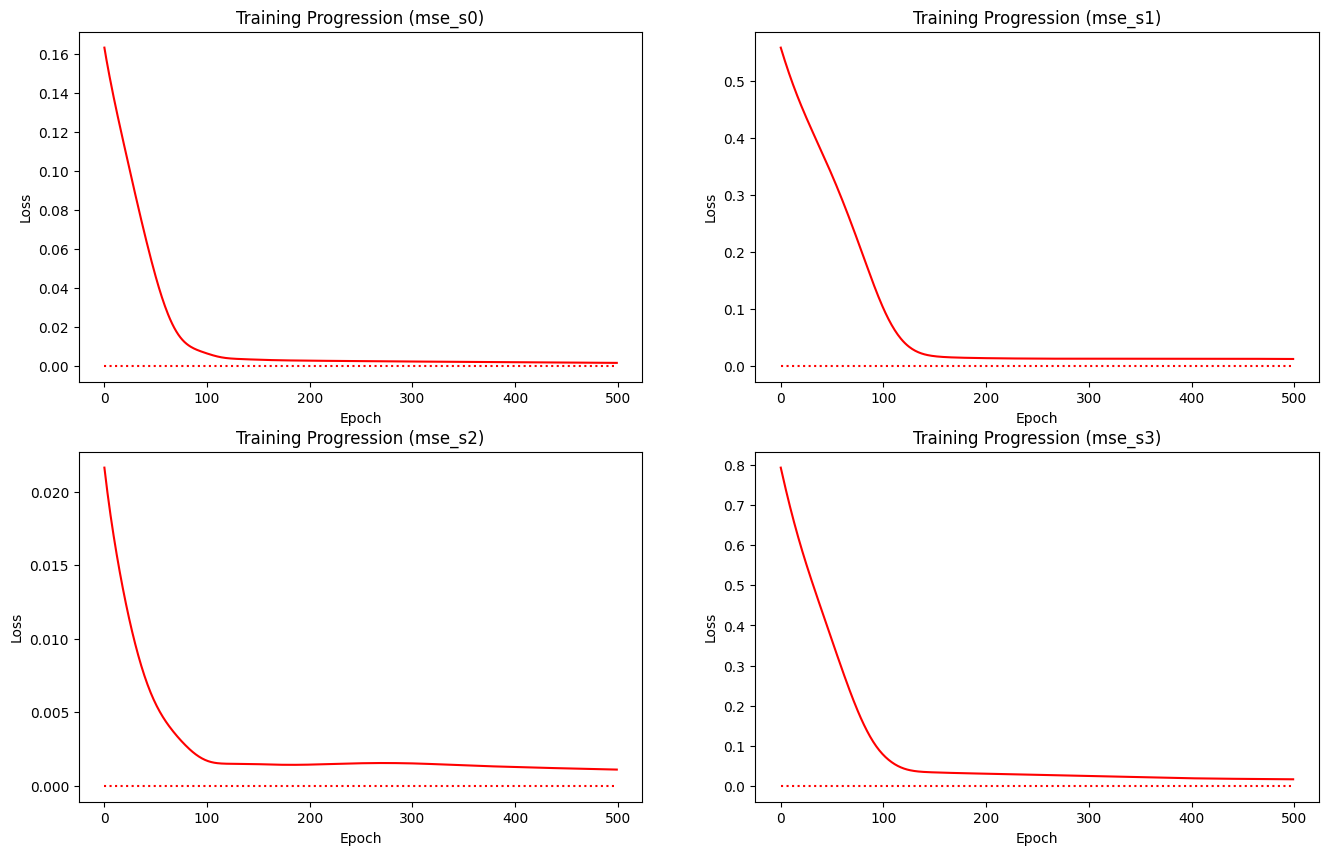

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = data.get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

In [6]:
df.head()

,epoch,triplet,mse_s,transition,reward,mse_s0,mse_s1,mse_s2,mse_s3
0,0,1.119077,"[0.16308407485485077, 0.5584057569503784, 0.02...",2.655901,0.328745,0.163084,0.558406,0.021647,0.793687
1,1,1.119073,"[0.15986284613609314, 0.5524997711181641, 0.02...",2.634907,0.328687,0.159863,0.552500,0.021054,0.782417
2,2,1.119065,"[0.1568751037120819, 0.5466805100440979, 0.020...",2.614244,0.328645,0.156875,0.546681,0.020482,0.771142
3,3,1.119053,"[0.153971865773201, 0.5409521460533142, 0.0199...",2.593910,0.328603,0.153972,0.540952,0.019932,0.760001
4,4,1.119036,"[0.1511337161064148, 0.5353106260299683, 0.019...",2.573894,0.328556,0.151134,0.535311,0.019403,0.749010


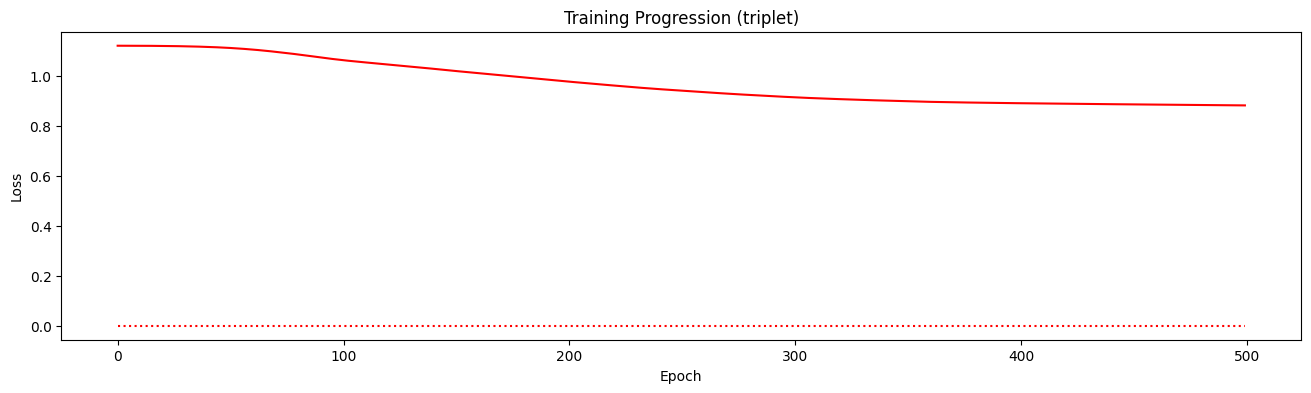

In [7]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))

data.plot_training_loss(axs, df['triplet'], 'r')

plt.show()

# Evaluation

In [8]:
results = data.evaluate_model(model, n_episodes=10)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.25, 0.5)","[0.046, 0.002, 0.041, 0.009]",0,1.0,"[0.046, -0.195, 0.042, 0.352]",1.0,1.0,"[0.042, 0.001, 0.049, 0.038]","[-0.001, -0.109, 0.011, 0.134]","(0.25, 2.64)",0.6
1,1,0,"(0.25, 0.5)","[0.046, -0.195, 0.042, 0.352]",1,1.0,"[0.042, 0.001, 0.049, 0.038]",0.0,1.0,"[0.042, -0.196, 0.049, 0.384]","[0.023, -0.216, 0.019, 0.269]","(0.52, 3.09)",0.6
2,2,0,"(0.25, 0.5)","[0.042, 0.001, 0.049, 0.038]",0,1.0,"[0.042, -0.196, 0.049, 0.384]",0.0,1.0,"[0.039, -0.394, 0.057, 0.729]","[-0.003, -0.501, 0.026, 0.573]","(0.25, 2.7)",0.6
3,3,0,"(0.25, 0.5)","[0.042, -0.196, 0.049, 0.384]",0,1.0,"[0.039, -0.394, 0.057, 0.729]",1.0,1.0,"[0.031, -0.198, 0.072, 0.422]","[-0.035, -0.415, 0.054, 0.496]","(0.27, 3.6)",0.6
4,4,0,"(0.25, 0.5)","[0.039, -0.394, 0.057, 0.729]",1,1.0,"[0.031, -0.198, 0.072, 0.422]",0.0,1.0,"[0.027, -0.396, 0.08, 0.774]","[-0.006, -0.532, 0.064, 0.648]","(0.53, 4.06)",0.6


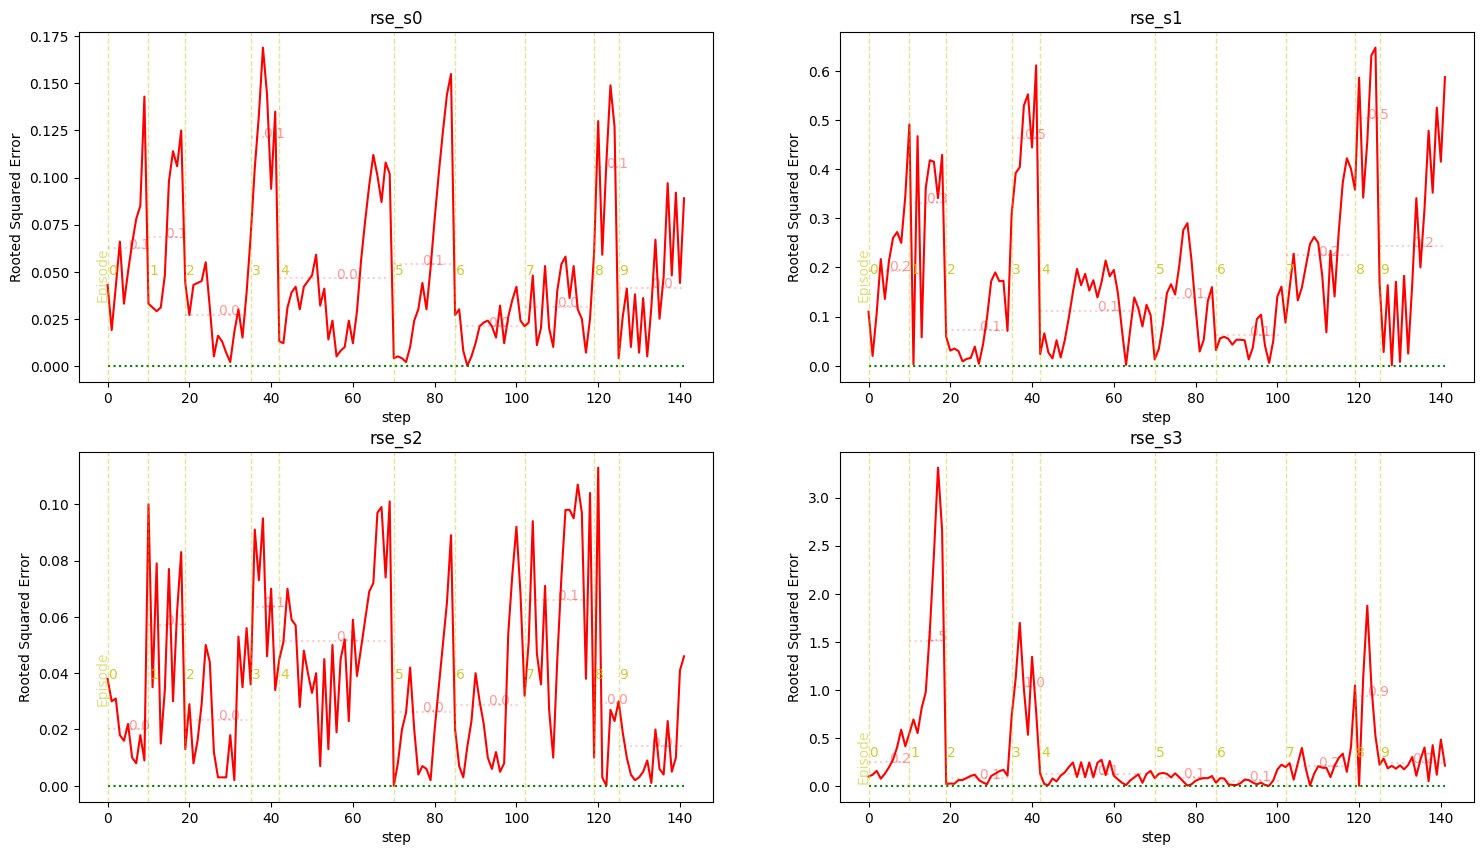

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

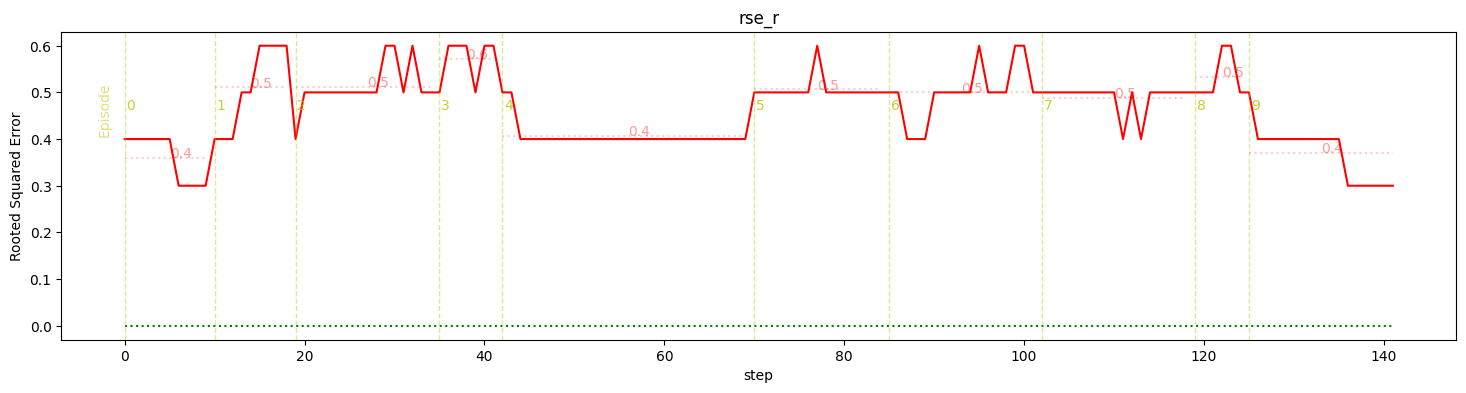

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

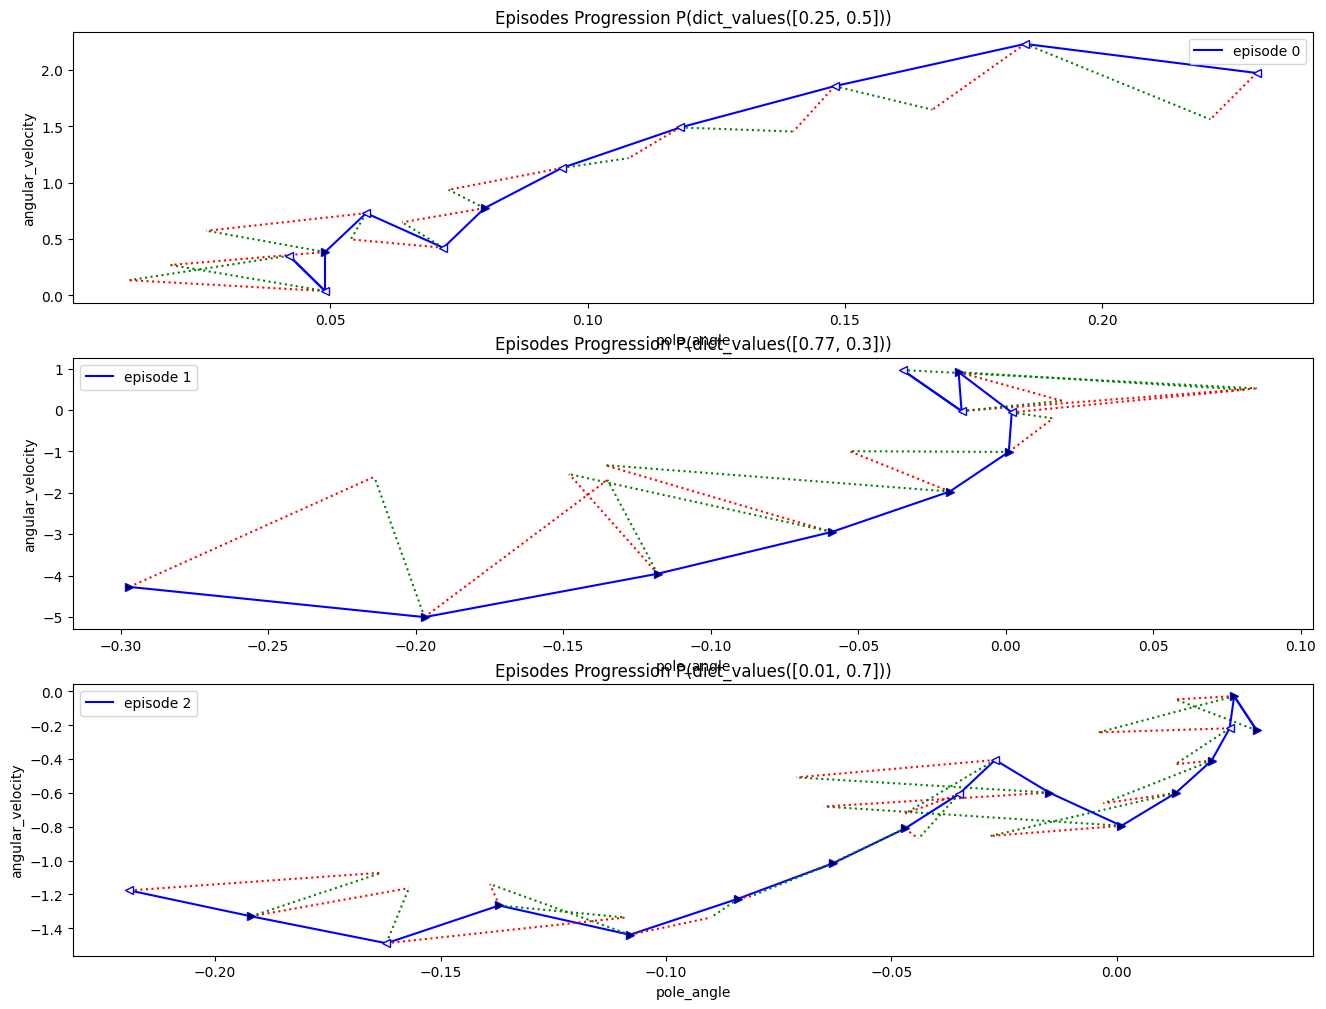

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()